In [ ]:
#TASK 1

import pandas as pd

# Load dataset
df = pd.read_csv("/content/online_retail_II.csv", encoding='latin-1')


In [ ]:
df.shape

(525461, 8)

In [ ]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [ ]:
df.dtypes

,0
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
Price,float64
Customer ID,float64
Country,object


In [ ]:
#EXPLANATION FOR TASK 1
The Online Retail dataset defines invoice line items as a single row. To put it in simpler terms, it is equivalent to a single product purchased at a specific quantity for a certain price in a given transaction, at a specific point in time.
As one invoice (or shopping basket) may contain more than one product, which are each contained in a distinct row, multiple rows may have the same invoice number.
If one customer makes more than one purchase over time or if more than one item is purchased on a single invoice by the same customer, then multiple rows would also have the same Customer ID.
This means that rows in this dataset are part of some larger transactional structures, not distinct observations.

In [ ]:
#TASK 2
1. Invoice line (row level)
What it represents:
One product purchased (or returned) in a single transaction.
Information gained
Product-level detail (StockCode, Description, Price).
Ability to analyse returns via negative quantities.
Fine-grained revenue calculations per item.
Information lost
No direct view of a customer’s full basket.
Customer behaviour is fragmented across many rows.
Difficult to interpret intent (e.g. “big purchase” vs many small items).

2.Invoice / basket level
What it represents:
All items purchased together in one invoice.
Information gained
Basket size, total invoice value, and number of items.
Enables market-basket and co-purchase analysis.
More realistic representation of a shopping event.
Information lost
Individual product price/quantity variation is aggregated away.
Less detail about item-level returns.
Still treats repeat visits by the same customer as independent events.

3. Customer level (aggregated across all invoices)
What it represents:
Overall behaviour of each customer across the dataset.
Information gained
Total spend, total orders, average basket value.
Enables customer segmentation (e.g. high vs low value customers).
Reduces noise from individual transactions.
Information lost
Timing and evolution of behaviour is removed.
Cannot study seasonality or behaviour changes.
Basket composition and purchase context are lost.

#DECISION
Decision
Chosen unit of analysis: Customer over a time window (monthly behaviour)
Justification
It balances detail and interpretability: more informative than a single customer aggregate, but less noisy than invoice lines.
Suitable for Week 2 onward tasks, such as feature engineering, behavioural modelling, and segmentation.
Avoids treating repeated purchases as independent while still capturing meaningful change over time.
Conclusion:
Using customer–month as the unit of analysis provides the most analytically useful and conceptually valid representation for downstream modelling and behavioural analysis.




In [ ]:
#TASK 3
 Data Quality and Validity Audit.
 Here we identify five data quality / validity issues in the dataset, explain their importance analytically and how these issues will be dealt with.

Issue #1: Missing or invalid Customer ID.

Description
Customer ID missing in a non-trivial number of rows. Each of these transactions cannot be traced back to one particular customer.

Why it matters
It blocks aggregation at the customer level.
It biases consumer metrics such as frequency, lifetime value.
Makes retention / behavioural analysis impossible for those rows.

Planned handling
Do not consider these from customer-level point of view (beginning from Week 2 onward).
Preserve for transaction-based revenue summaries if necessary.
Reason: customer identity cannot be imputed, it generates false structure.

Issue 2: Negative quantities (returns).

Description
Quantity < 0 can be seen in the data. These are the equivalent of returned items.

Why it matters
If you treat them as normal purchases, it distorts sales volume and revenue.
Returns vary in behaviour from purchases.

Planned handling
With an indicator variable: Keep but flag as returns.
Separate analyses:
gross sales (purchases only),
net revenue (purchases − returns).
Reasoning: returns matter economically, not mistake-wise.

Issue 3: Cancelled invoices.

Description
Invoice numbers starting with "C" correspond to cancellations. These often accompany negative quantities and prices.

Why it matters
Cancelled invoices are counted as sales which inflate transaction count.
Can skew basket-level and customer-level statistics.

Planned handling
Do not include cancelled invoices within the analysis of primary purchases.
Keep a separate dataset of cancellations for use in operational understanding.
Rationale: cancellations are failed transactions, not real demand.

Issue 4: Extreme prices and quantities.

Description
High prices and very large quantities emerge. Some are close to zero or even zero.

Why it matters
Skews averages and variance.
May dominate models and EDA visuals.
Certain extreme values indicate artefacts due to data entry or adjustment.

Planned handling
Explore extremes contextually (e.g. bulk orders vs errors).
For EDA - use winsorisation or percentile clipping.
Keep the raw values for revenue calculations.
Rationale: remove distortion but not eliminate actual high-value customers.

Issue 5: Country imbalance.

Description
Most of the transactions are from the United Kingdom. Many other countries have sample sizes that are very small.

Why it matters
Country-to-country comparisons become unstable.
Models may just learn “UK vs non-UK”.

Planned handling
Treat UK as a baseline category.
Group low-frequency countries into an "Other" category when modelling.
Rationale: increases statistical stability and interpretability.

Conclusion
These aren’t just "errors" but actual retail processes. Decision making is driven by analytic validity rather than cosmetic cleaning, so that downstream modelling and interpretation is credible.

In [ ]:
#TASK 4
1.Handling The missing cutomers ID
#Description
Some transactions don’t include a Customer ID.
This matters because, without it, we can’t link purchases to the same person, which makes customer-level and behavioural analysis impossible.



In [4]:
import pandas as pd

# Load dataset (moved from an earlier cell to fix NameError in this cell)
df = pd.read_csv("/content/online_retail_II.csv", encoding='latin-1')

#Before cleaning
df['Customer ID'].isna().sum()

np.int64(80575)

In [6]:
#CLEANING STEP
df_clean = df.dropna(subset=['Customer ID'])

In [7]:
#AFTER CLEANING
df_clean['Customer ID'].isna().sum()

np.int64(0)

In [ ]:
#Impact of the decision.
Eliminating rows with missing Customer IDs reduces the size of the dataset, but guarantees that all other transactions accurately trace to unique customers, and therefore increases the validity of customer-level analysis.

In [ ]:
#SEPARATION OF PURCHASES
Description

Some of the rows contain negative values in the Quantity column, which represent product returns rather than purchases.
Returns shouldn’t be seen as sales because they distort revenue, basket size, and purchase frequency estimates

In [8]:
#BEFORE CLEANING
(df_clean['Quantity'] < 0).sum()

np.int64(8027)

In [9]:
#CLEANING STPES
purchases = df_clean[df_clean['Quantity'] > 0].copy()
returns = df_clean[df_clean['Quantity'] < 0].copy()

In [10]:
#AFTER CLEANING
purchases.shape, returns.shape

((316313, 8), (8027, 8))

<Axes: title={'center': 'Number of Purchases Over Time'}, xlabel='InvoiceDate'>

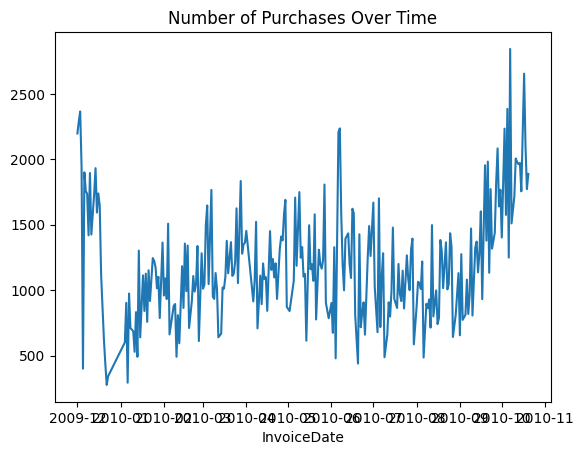

In [11]:
#TASK 5
#EDA OUTPUT 1(PURCHASES OVER TIME)
purchases['InvoiceDate'] = pd.to_datetime(purchases['InvoiceDate'], dayfirst=True)

# Number of purchases over time
purchases_per_day = purchases.groupby(
    purchases['InvoiceDate'].dt.date
).size()

purchases_per_day.plot(title="Number of Purchases Over Time")

In [ ]:
#Key pattern:
There are changes in the number of purchases over time.
Seasonal or temporal purchasing trends might have seasonal or time-based behavior, when some periods show more transactions than others.

#Limitation:
This review considers only the quantity of purchases, the amount spent and whether or not items were returned are not taken into account.

<Axes: title={'center': 'Revenue Over Time'}, xlabel='InvoiceDate'>

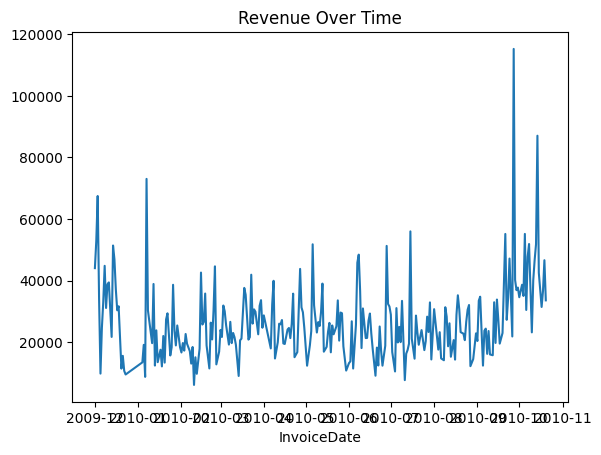

In [12]:
#EDA OUTPUT 2(REVENUE ACROSS TIME)
purchases['InvoiceDate'] = pd.to_datetime(purchases['InvoiceDate'], dayfirst=True)
# Create revenue column
purchases['Revenue'] = purchases['Quantity'] * purchases['Price']

# Revenue over time
revenue_over_time = purchases.groupby(
    purchases['InvoiceDate'].dt.date
)['Revenue'].sum()

revenue_over_time.plot(title="Revenue Over Time")


In [ ]:
#Question:
What is the evolution of revenue over time?
By multiplying quantity by unit of price
Limitations:
Some of the large orders have significant price differences.

<Axes: title={'center': 'Basket Size Distribution'}, ylabel='Frequency'>

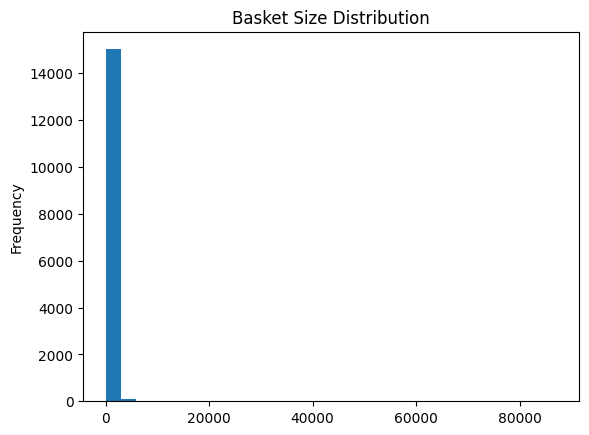

In [13]:
#EDA Output 3 A product or country pattern
# Basket size per invoice
basket_size = purchases.groupby('Invoice')['Quantity'].sum()

basket_size.plot(kind='hist', bins=30, title="Basket Size Distribution")

In [ ]:
#Question:

On an invoice, how many items are usually purchased?
Small number of items can be purchased on invoices and the small items have large basket size
Limitations:
Monetary value is not taken into account.

In [ ]:
#EDA Output 4
 Invoice value distribution (The Transactional pattern).


<Axes: title={'center': 'Invoice Value Distribution'}, ylabel='Frequency'>

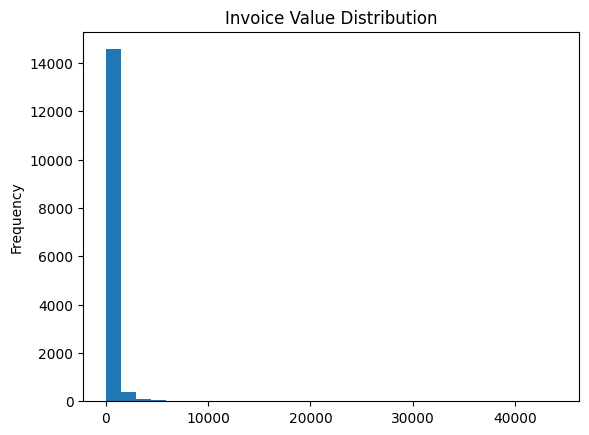

In [14]:
# Invoice value
invoice_value = purchases.groupby('Invoice')['Revenue'].sum()

invoice_value.plot(kind='hist', bins=30, title="Invoice Value Distribution")


In [ ]:
#Question:

What is the invoice value distribution?
There are few high-value transactions among the majority of invoices with low total values.

In [ ]:
#TASK 6
3 Key Insights from week 1

Transaction behaviour is highly skewed.
Most invoices are small, but a small number of large baskets and high-value customers contribute a disproportionate share of total revenue.
Strong temporal and seasonal patterns exist.
Revenue varies substantially over time, with clear end-of-year peaks, indicating seasonality that must be accounted for in analysis and modelling.
Returns and cancellations are structurally important.
Negative quantities and cancelled invoices are not errors but reflect real business processes; ignoring them would bias revenue and demand estimates.

2 assumptions or risks

Customer identity completeness
Analyses assume that rows with valid Customer IDs are representative; customers with missing IDs may introduce selection bias.
Stationarity within time windows
Aggregating behaviour over fixed periods (e.g. monthly) assumes customer behaviour is relatively stable within those windows, which may not always hold.

Chosen unit of analysis.
Customer–month (customer behaviour aggregated over monthly time windows).
This unit achieves a compromise between transactional granularity and interpretability, maintains temporal fidelity, and does not characterize repurchase as stand-alone events.

Modelling Task.
The next step is to build a customer-level behavioural model to predict future purchase activity or customer value using historical transaction features aggregated by month.
This will allow segmentation and early identification of high-value or at-risk customers.


